In [ ]:
# ====== 1. Upload File CSV ======
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


#SOAL NO 4 Statistics

## 1. Load data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Ambil nama file yang di-upload
filename = list(uploaded.keys())[0]
print("File uploaded:", filename)

# ====== 2. Baca CSV ======
df = pd.read_csv(filename, sep=';')
df.head()

File uploaded: dataset (1).csv


,id,order_date,user_id,product_id,quantity
0,24,03/01/2019,62746,1,1
1,8989,01/01/2019,53424,28,1
2,8990,01/01/2019,53424,28,1
3,8991,01/01/2019,53424,28,1
4,8992,01/01/2019,53424,28,1


## 2. Mengetahi bentuk awal dari dengan melakukan agregasi jumlah pembelian per customer


In [ ]:
# 2. Aggregate total per customer
user_totals = df.groupby('user_id', as_index=False)['quantity'].sum().rename(columns={'quantity':'total_quantity'})
values = user_totals['total_quantity'].values
print("N users:", len(values))
print(user_totals.describe())

# 3. Quick diagnostics
mean = values.mean()
var = values.var(ddof=1)
print("Mean:", mean, "Variance:", var)
print("Overdispersion? (var > mean) ->", var > mean)

N users: 28068
             user_id  total_quantity
count   28068.000000    28068.000000
mean    87033.767850       22.860446
std     29805.759949       66.314354
min         6.000000       -3.000000
25%     72348.250000        4.000000
50%     89434.500000        8.000000
75%    107723.250000       23.000000
max    139605.000000     4058.000000
Mean: 22.860446059569618 Variance: 4397.593485845132
Overdispersion? (var > mean) -> True


Berdasarkan nilai statistik, bisa kita lihat bahwa nilai median adalah 8, artinya hampir separuh customer membeli dengan jumalh 8 qty. Sedangkan rata-rata seluruh data adalah 23. Ini berarti sebagian besar customer berada di rentang pembelian rendah. Tapi ada sebagian kecil customer yang membeli sangat banyak, sehingga “menarik” mean ke atas. Sedangkan Max pembelian sendiri juga terpaut sangat besar = 4058

| Statistik            | Nilai | Arti                                          |
| -------------------- | ----- | --------------------------------------------- |
| **Mean (rata-rata)** | 22.86 | Rata-rata cust membeli 23 item.  |
| **Median (50%)**     | 8     | Setengah cust membeli **8 item atau kurang**. |
| **75%**              | 23    | 75% cust beli **≤ 23 item**.                  |
| **Max**              | 4058  | Ada cust ekstrem yang beli **ribuan** item.   |


**Ini adalah ciri distribusi yang tidak simetris dan ber-ekor panjang (heavy tail)**

Lalu hasil menunjukkan var > mean artinya, distribusi count normal (Poisson) tidak bisa cocok—karena Poisson mengharuskan variance ≈ mean.

## 3. Cek menggunakan Histogram linear dan Histogram log scale (y) untuk melihat bentuk dasar distribusi

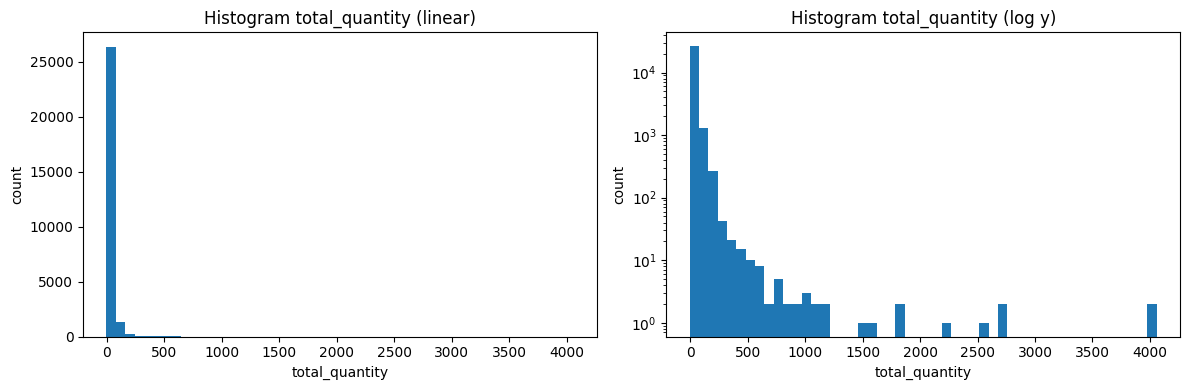

In [ ]:
# 4. Plot histogram (linear + log scale) to inspect tail
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(values, bins=50)
plt.title("Histogram total_quantity (linear)")
plt.xlabel("total_quantity"); plt.ylabel("count")

plt.subplot(1,2,2)
plt.hist(values, bins=50, log=True)
plt.title("Histogram total_quantity (log y)")
plt.xlabel("total_quantity"); plt.ylabel("count")
plt.tight_layout()
plt.show()

* Pada gambar histogram linear, terlihat total quantity terpusat di kiri, namun grafik membentang panjang ke sumbu x dengan nilai yang sangat besar (4000++). Grafiknya tidak simetris, lebih terpusat ke kiri dengan ekor panjang ke kanan.

**artinya:
→ Tanda distribusi right-skewed (positively skewed)
→ Ada heavy users (sedikit user membeli sangat banyak)**


* Pada gambar histogram log scale, bentuknya jadi lebih halus, terlihat seperti garis menurun eksponensial.

**artinya:
→ jumlah user yang beli lebih banyak turun sangat cepat
→ tapi tidak pernah benar-benar nol
→ menandakan long-tail distribution**

* Ini adalah ciri-ciri data yang bukan distribusi ringan/normal, tetapi **heavy-tailed distribution**.

* Distribusi probabilitas yang memungkinkan: Lognormal Distribution atau Power Law / Pareto.


## 4. Identifikasi heavy tail dengan log–log CCDF

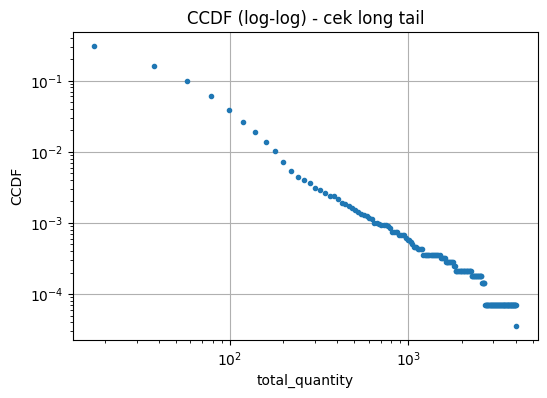

In [ ]:
# Plot CCDF (Complementary CDF) untuk melihat heavy-tail
counts, bin_edges = np.histogram(values, bins=200, density=False)
cdf = np.cumsum(counts)/counts.sum()
ccdf = 1 - cdf
plt.figure(figsize=(6,4))
plt.loglog(bin_edges[1:], ccdf, marker='.', linestyle='none')
plt.title("CCDF (log-log) - cek long tail")
plt.xlabel("total_quantity"); plt.ylabel("CCDF")
plt.grid(True); plt.show()

Berdasarkan grafik:
- grafik menurun cukup smooth
- Tidak lurus sempurna, sedikit melengkung
- Ada derau di bagian ekor (karena data mulai jarang)
- Ekor memanjang sampai nilai besar (long tail)

Grafik log–log CCDF: membedakan jenis distribusi

a. Power Law/Pareto
memiliki ciri-ciri:
- CCDF log-log terlihat garis lurus panjang
- tail tidak pernah “habis” dan tetap tebal

Sedangkan grafik tidak lurus sempurna.
→ Kemungkinan bukan pure power law.


b. Lognormal Distribution
memiliki ciri-ciri:
- bentuknya puncak di kiri dan ekor panjang ke kanan
- ketika dibuat histogram log-scale, bentuknya jadi lebih “normal”

→ Maka distribusi probabilitas yang cocok berdasarkan ciri dan identifikasi di atas adalah **Lognormal**

## 5. Grafik Distribusi Lognormal

Lognormal params:
shape: 1.2930919473492162
loc: 0
scale: 9.213976517995512


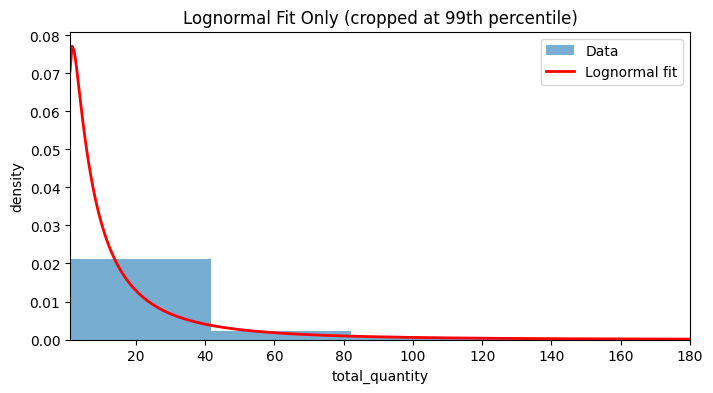

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# pastikan kolom quantity numerik
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').fillna(0).astype(int)

# hitung total per user
user_totals = df.groupby('user_id')['quantity'].sum().reset_index()
values = user_totals['quantity'].values

# gunakan hanya nilai > 0 untuk lognormal
pos = values[values > 0]

# --- Fit lognormal ---
shape, loc, scale = stats.lognorm.fit(pos, floc=0)

print("Lognormal params:")
print("shape:", shape)
print("loc:", loc)
print("scale:", scale)

# --- Plot histogram + lognormal ---
plt.figure(figsize=(8,4))

# histogram data user
plt.hist(pos, bins=100, density=True, alpha=0.6, label="Data")

# kurva lognormal
x = np.linspace(1, np.percentile(pos, 99), 300)
pdf = stats.lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf, 'r-', linewidth=2, label="Lognormal fit")

plt.xlim(1, np.percentile(pos, 99))
plt.xlabel("total_quantity")
plt.ylabel("density")
plt.title("Lognormal Fit Only (cropped at 99th percentile)")
plt.legend()
plt.show()


Analisis distribusi menunjukkan bahwa data memiliki pola lognormal dengan ekor panjang, di mana sebagian besar SKU memiliki permintaan rendah, sementara sebagian kecil SKU menyumbang porsi terbesar dari total penjualan. Kondisi ini menandakan adanya ketimpangan kontribusi antar produk.


## 6. Rekomendasi bisnis

Rekomendasi bisnis yang relevan adalah:

* Prioritasi SKU ber-volume tinggi melalui penguatan stok, promosi, dan visibilitas untuk menjaga stabilitas kontribusi penjualan utama.

* Diferensiasi manajemen stok, dengan stok aman lebih besar untuk SKU high-impact dan stok efisien untuk SKU low-demand.

* Optimalisasi alokasi budget pemasaran dengan fokus pada produk yang memberikan dampak penjualan terbesar.

* Penerapan monitoring dini pada SKU yang fluktuatif untuk mendeteksi lonjakan permintaan secara cepat.

* Strategi ini membantu perusahaan memaksimalkan performa SKU penting, meningkatkan efisiensi biaya, dan mengurangi risiko kehilangan penjualan pada produk utama.